# Monitoraggio della reputazione online tramite Sentiment Analysis

Questo notebook implementa un sistema di analisi del sentiment utilizzando il modello pre-addestrato:

cardiffnlp/twitter-roberta-base-sentiment-latest

Il modello viene testato su un dataset pubblico (TweetEval) per classificare testi social in:
- Positive
- Neutral
- Negative

**Fase 1 del progetto MLOps**

In questa fase viene utilizzato il modello pre-addestrato twitter-roberta-base-sentiment-latest per classificare il sentiment di testi provenienti da un dataset pubblico (tweet_eval). L’obiettivo è valutare le prestazioni del modello come baseline prima di eventuali fasi di fine-tuning o retraining richiesti nella successiva fase del progetto.


####Il flusso della prima fase è questo:
TweetEval dataset -> twitter-roberta-base-sentiment-latest->predizioni-> accuracy / F1 / confusion matrix

Facendo in questo modo avrò sia le metriche dell'algoritmo senza fine -tuning che dopo nella fase 2 la versione fined.





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score


ModuleNotFoundError: No module named 'matplotlib'

#### Testo il modello su un piccolo dataset realizato ad hoc per dimostrare il funzionamento della pipeline e la correttezza del

####Test rapido del modello

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

examples = [
    "I love this company!",
    "The service is terrible.",
    "The update was released today."
]

for text in examples:
    print(text)
    print(classifier(text))
    print("------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


I love this company!
[{'label': 'positive', 'score': 0.9863932728767395}]
------
The service is terrible.
[{'label': 'negative', 'score': 0.9320089221000671}]
------
The update was released today.
[{'label': 'neutral', 'score': 0.7817121744155884}]
------


####I risultati sono incoraggianti :
#####I love this company! [{'label': 'positive', 'score': 0.9863932728767395}]
------
#####The service is terrible. [{'label': 'negative', 'score': 0.9320089221000671}]
------
#####The update was released today. [{'label': 'neutral', 'score': 0.7817121744155884}]

#Dataset pubblico scelto: cardiffnlp/tweet_eval


*   è lo stesso benchmark usato per addestrare il modello RoBERTa che stai usando
*   contiene tweet reali
*   ha 3 classi: negative - neutral -positive
*   ha già train / validation / test split
*   è stato fine-tuned proprio su TweetEval dopo essere stato pre-addestrato su circa 124 milioni di tweet

Il benchmark TweetEval include diversi task sui tweet, tra cui sentiment analysis con le tre classi principali

In [ ]:
from datasets import load_dataset

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

train_data = dataset["train"]
test_data = dataset["test"]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

#train_data[0]

test_df = pd.DataFrame(dataset["test"])
test_df.head()

Train size: 45615
Test size: 12284


,text,label
0,@user @user what do these '1/2 naked pics' hav...,1
1,OH: “I had a blue penis while I was this” [pla...,1
2,"@user @user That's coming, but I think the vic...",1
3,I think I may be finally in with the in crowd ...,2
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",0


####Preparazione del dataset con la mappatura

In [ ]:
label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

test_df["true_label"] = test_df["label"].map(label_map)
test_df.head()

,text,label,true_label
0,@user @user what do these '1/2 naked pics' hav...,1,neutral
1,OH: “I had a blue penis while I was this” [pla...,1,neutral
2,"@user @user That's coming, but I think the vic...",1,neutral
3,I think I may be finally in with the in crowd ...,2,positive
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",0,negative


###Predizione su tutto il dataset

In [ ]:
def predict_sentiment(text):
    result = classifier(text)[0]
    return result["label"].lower()

####Predizione su solo una parte 1000 tweet

In [ ]:
sample_df = test_df.sample(1000, random_state=42)

sample_df["predicted_label"] = sample_df["text"].apply(predict_sentiment)

sample_df.head()

,text,label,true_label,predicted_label
450,Do you think Michelle Obama wanted to smack Me...,1,neutral,neutral
9197,Well that finale was one big mindfuck 😳 #Westw...,1,neutral,negative
2864,"Luis Enrique: ""In the first half I can't remem...",1,neutral,neutral
4978,Happy Thanksgiving from a couple of bad hombre...,2,positive,positive
518,@user Viper. Another fucking nazi,0,negative,negative


###Calcolo delle metriche

In [ ]:
accuracy = accuracy_score(sample_df["true_label"], sample_df["predicted_label"])

macro_f1 = f1_score(
    sample_df["true_label"],
    sample_df["predicted_label"],
    average="macro"
)

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

print(classification_report(
    sample_df["true_label"],
    sample_df["predicted_label"]
))

Accuracy: 0.7
Macro F1: 0.7020881794032495
              precision    recall  f1-score   support

    negative       0.69      0.79      0.73       328
     neutral       0.72      0.63      0.67       462
    positive       0.69      0.70      0.70       210

    accuracy                           0.70      1000
   macro avg       0.70      0.71      0.70      1000
weighted avg       0.70      0.70      0.70      1000



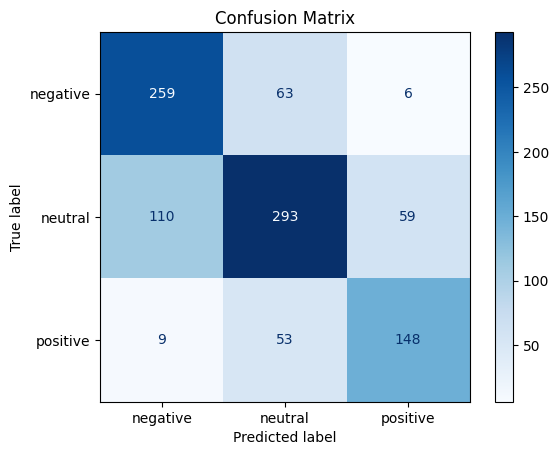

In [ ]:
labels_order = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    sample_df["true_label"],
    sample_df["predicted_label"],
    labels=labels_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_order
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

###Analisi errori

In [ ]:
errors_df = sample_df[
    sample_df["true_label"] != sample_df["predicted_label"]
]

errors_df[["text", "true_label", "predicted_label"]].head(10)

,text,true_label,predicted_label
9197,Well that finale was one big mindfuck 😳 #Westw...,neutral,negative
2894,Wow! Liberals are now asking for a refund from...,negative,neutral
3468,@user Electoral college was created so that th...,positive,neutral
10699,if insert coin sells persona 5 gear thats nice...,neutral,positive
3002,I can and will fight for #BlackLivesMatter . H...,positive,neutral
218,The The Orlando #Python User Group meetup is h...,positive,neutral
8128,Sunday: Football. American football. Dolores P...,neutral,positive
4279,"""US changes vote on UN resolution against Cuba...",neutral,negative
2802,Putin ally warns Russia is heading towards the...,neutral,negative
10963,@user Unlike you I actually take Ephesians 6:1...,neutral,negative


## Conclusioni

In questa fase è stato implementato un sistema di sentiment analysis utilizzando il modello pre-addestrato `twitter-roberta-base-sentiment-latest`.

Il modello è stato testato su un dataset pubblico di tweet (TweetEval) e valutato tramite diverse metriche di classificazione.

I risultati mostrano che il modello è in grado di classificare correttamente la maggior parte dei testi social in sentiment positivo, neutro o negativo.

Questa baseline verrà utilizzata nelle fasi successive del progetto per integrare pipeline CI/CD e sistemi di monitoraggio continuo.